## (72 points possible)

# Problem 1:  Graphing (20 pts [5, 7, 8])


a, 5 pts) The lists provided give the 2025 GDPs of the US, China, Germany, India, Japan, and the UK (in trillions of dollars), and also their populations in that same order (in millions). Plot these with matplotlib.pyplot as a scatter plot, with population as the X axis and GDP as the Y axis.  Also, label the x and y axes using plt.xlabel() and plt.ylabel().

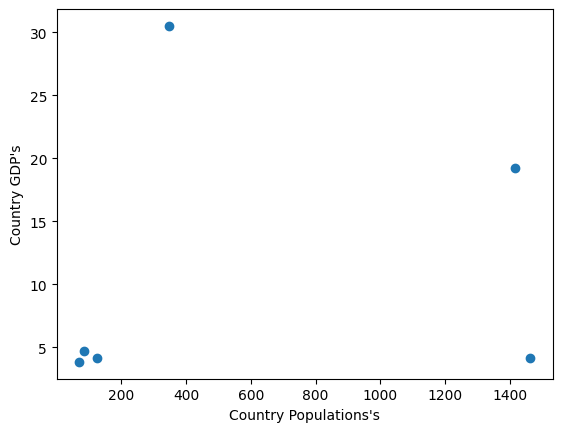

In [13]:
gdps = [30.51, 19.23, 4.74, 4.19, 4.18, 3.84]
pops = [347, 1416, 84, 1464, 123, 70]

# TODO
import matplotlib.pyplot as plt
import numpy as np

y = np.array(gdps)
x = np.array(pops)

plt.scatter(x,y)

plt.ylabel("Country GDP's")
plt.xlabel("Country Populations's")

plt.show()


b, 7pts) Plot the same graph (including the axis labels) again but with additional trendline in red of y = 0.00275x + 9.5, plotted as a line graph on top of the original points, which should now be a scatter plot. Hint:  You just need two points of the line to plot the line, one for x=0 and one for x=1600.

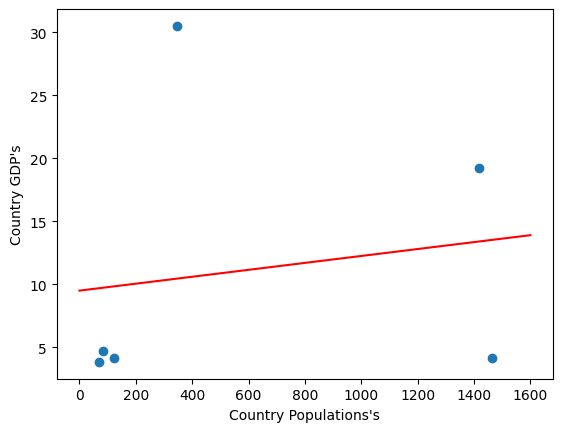

In [14]:
# TODO
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(x,y)


xValues = np.linspace(0,1600)
def trend(x):
    return 0.00275*x+9.5
yValues = trend(xValues)

plt.plot(xValues,yValues,color="red")

plt.ylabel("Country GDP's")
plt.xlabel("Country Populations's")
plt.show()

c, 8 pts) To *overfit* data is to use a model that is complicated enough to capture even irrelevant details that one shouldn't make generalizations about - fitting the training data but making bad predictions.  We can generalize these points by noting they look more like a parabola than anything else, even though it doesn't really make sense to think of GDP as falling when population gets high enough.  Still, plot the parabola $-8.1 + .143x - 0.00009x^2$ in red on top of your scatter plot, using linspace to generate x coordinates from 0 to 1600 and using broadcasting to calculate the associated y values.  You should keep your x and y axis labels, but you don't need the fit line from the previous problem.

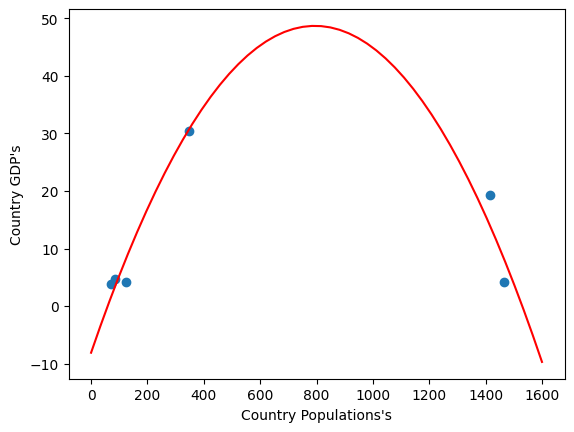

In [20]:
# TODO

import matplotlib.pyplot as plt
import numpy as np

plt.scatter(x,y)


xValues = np.linspace(0,1600)


def parabola(x):
    return -8.1+0.143*x-0.00009*(x**2)
parabolaValues = parabola(xValues)
plt.plot(xValues,parabolaValues,color = "red")
plt.ylabel("Country GDP's")
plt.xlabel("Country Populations's")
plt.show()

# Problem 2:  Similar vectors (10 points [6, 4])

As we'll explore later in the course, vectors (1D arrays of numbers) can be mathematical representations of words, documents, or concepts.  In a recommendation system that recommends movies based on what you just watched, one vector might represent the movie you just watched, and all the other movies you could watch next are also representable by vectors.  The vectors that are most similar to your vector are the ones that are most likely to be recommended.

a, 6 pts) One operation that is commonly used for determining vector similarity is the *dot product*, which produces a number that is more positive the more similar vectors are.  (Dot products of 0 correspond to orthogonal, or unrelated, vectors.)  Write a function most_similar(v, A) that iterates through the rows of matrix A to find a row that has the largest dot product with 1D vector v.  You can assume the vector has as many elements as A has columns, and that v and A aren't empty.  You can use np.dot() to find a dot product of two vectors.  You can assume the best dot product is at least -1.

In [38]:
# TODO
def most_similar(arr1, arr2):
    best_dot = -1
    best_row = None
    
    for row in arr2:
        dp = np.dot(arr1, row)   # compute dot product
        if dp > best_dot:
            best_dot = dp
            best_row = row
            
    return best_row

In [39]:
A = np.array([[-1, 1, -1], [-1, -1, -1], [1, 1, 1]])
v = np.array([[-1, 0.5, -1]])
print(most_similar(v, A)) # Expect [-1, 1, -1]

[-1  1 -1]


b, 4 pts) Write a similar function most_similar_col() that instead computes the *column* that has the largest dot product with v.

In [40]:
# TODO




def most_similar_col(arr1, arr2):
    best_dot = -1  
    best_col = None
    
    for col in arr2.T:   # iterate over columns
        dp = np.dot(arr1, col)
        if dp > best_dot:
            best_dot = dp
            best_col = col
            
    return best_col

In [41]:
A = np.array([[-1, 1, -1], [-1, -1, -1], [1, 1, 1]])
v = np.array([[1, -0.5, 1]])
print(most_similar_col(v, A)) # Expect [1, -1, 1]

[ 1 -1  1]


# Problem 3:  Nested loops and numpy arrays (10 pts [5, 5])

3D points can be represented by vectors of 3 coordinates, $\begin{bmatrix}x\\y\\z\end{bmatrix}$.  These in turn can be represented by 3 element numpy arrays.  We can therefore represent a triangle as a matrix with 3 columns, $\begin{bmatrix}x_1 & x_2 & x_3\\y_1 & y_2 & y_3\\z_1 & z_2 & z_3\end{bmatrix}$, which can in turn be represented with a $3 \times 3$ numpy matrix, with the columns representing the points of the triangle.

We could therefore represent a whole 3D model, such as of Woody from *Toy Story*, as a list of these matrices, with each little triangle a part of a surface to render.

And we could therefore represent a whole scene as a list-of-lists, where each list represents one of these 3D models.

In [43]:
import numpy as np

point1 = np.array([[0], [0], [0]])
point2 = np.array([[-1], [0], [0]])
point3 = np.array([[0], [1], [0]])
point4 = np.array([[0], [0], [1]])

triangle1 = np.hstack((point1, point4, point2))  # hstack concatenates columns side-by-side
triangle2 = np.hstack((point2, point1, point3))
triangle3 = np.hstack((point4, point1, point3))
triangle4 = np.hstack((point4, point2, point3))

model1 = [triangle1, triangle2, triangle3, triangle4]
model1

[array([[ 0,  0, -1],
        [ 0,  0,  0],
        [ 0,  1,  0]]),
 array([[-1,  0,  0],
        [ 0,  0,  1],
        [ 0,  0,  0]]),
 array([[0, 0, 0],
        [0, 0, 1],
        [1, 0, 0]]),
 array([[ 0, -1,  0],
        [ 0,  0,  1],
        [ 1,  0,  0]])]

a, 5 points) Write code that creates a new model, model2, that is the same as model1 but rotated 90 degrees around the x axis.  Matrix-multiplying $MT$ (M @ T in Python) will do this, where M is the rotation matrix and T is the triangle's matrix.  The rotation matrix is $\begin{bmatrix}1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0\end{bmatrix}$.  Inspect your results to see whether they make sense; the x coordinate shouldn't change, for example.  (Conventionally, x is toward the viewer, y is to the right, z is up, and this rotation should go counterclockwise.)

In [44]:
# TODO

M = np.array([
    [1, 0, 0],
    [0, 0, -1],
    [0, 1, 0]
])

# rotate all triangles in model1
model2 = [M @ triangle for triangle in model1]

b, 5 points) Write a function shiftx(models, delta) that adds *delta* to all the x coordinates of every triangle in every model in a list of models, *models*, returning the modified list of models.  

Note that one way to do this is to create a 3x3 matrix $\begin{bmatrix} \delta & \delta & \delta \\ 0 & 0 & 0 \\ 0 & 0 & 0\end{bmatrix}$, where $\delta$ is the delta argument, and add it to each of the triangle matrices.


In [45]:
# TODO
def shiftx(models, delta):
    new_models = []
    for model in models:
        new_model = []
        for triangle in model:
            shifted = triangle.copy()
            shifted[0, :] += delta   # add delta to x-coordinates (row 0)
            new_model.append(shifted)
        new_models.append(new_model)
    return new_models

In [46]:
shiftx([model1, model2], 10) # Expect [[array([[10, 10, 9], [0, 0, 0], [0, 1, 0]]), ...]]

[[array([[10, 10,  9],
         [ 0,  0,  0],
         [ 0,  1,  0]]),
  array([[ 9, 10, 10],
         [ 0,  0,  1],
         [ 0,  0,  0]]),
  array([[10, 10, 10],
         [ 0,  0,  1],
         [ 1,  0,  0]]),
  array([[10,  9, 10],
         [ 0,  0,  1],
         [ 1,  0,  0]])],
 [array([[10, 10,  9],
         [ 0, -1,  0],
         [ 0,  0,  0]]),
  array([[ 9, 10, 10],
         [ 0,  0,  0],
         [ 0,  0,  1]]),
  array([[10, 10, 10],
         [-1,  0,  0],
         [ 0,  0,  1]]),
  array([[10,  9, 10],
         [-1,  0,  0],
         [ 0,  0,  1]])]]

# Problem 4: Rotations in 2D (30 points [5, 5, 7, 3, 7, 3])

Recall from lecture that matrix-vector multiplication transforms one vector into another vector. This is an important operation, for instance, when rotating objects in a computer game. There is a specific 2D matrix for rotating vectors of length 2 (points in the xy plane) counterclockwise by an angle $\theta$ in radians. The matrix has the form:

$$
G =
\begin{pmatrix}
\cos{\theta} & -\sin{\theta} \\
\sin{\theta} & \cos{\theta}
\end{pmatrix}
$$.

Computing the matrix vector product $Gv$ rotates the vector $v$ counterclockwise by the angle $\theta$.

In this problem you need to code several functions that will allow you to rotate a vector by a specified degree. You will then write code to visualize how this vector rotates in the plane.

a, 5 pts) Write a function `create_rotation_matrix()` that takes in an angle in degrees. The output should be the rotation matrix corresponding to this angle using the above formula. Remember that to convert from degrees to radians you multiple by a factor of $\pi/180$. You may use either math or NumPy to import the fucntions $\cos$, $\sin$, and constant $\pi$. Test your function using an angle of $45^{\circ}$ and print the returned matrix, which should be np.arrray([[ 0.70710678 -0.70710678],[ 0.70710678  0.70710678]]).

In [47]:
# TODO

def create_rotation_matrix(angle):
    theta = np.deg2rad(angle)   # convert degrees → radians
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

# Test
print(create_rotation_matrix(45))

[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


b, 5 pts) Using your `create_rotation_matrix` function, write a new function `rotate_vector(vector, angle)` that takes as input a 2D vector and an angle in degrees, and returns the rotated vector. (Do not call a rotation function to do the rotation; use your matrix.)  Test your function using the angle $45^{\circ}$ and the vector $[1, 0]$, printing the rotated vector.

In [48]:
# TODO
def rotate_vector(vector, angle):
    R = create_rotation_matrix(angle)
    return R @ vector

# Test
print(rotate_vector(np.array([1, 0]), 45))

[0.70710678 0.70710678]


c, 7 pts) We now have functions to create a rotation matrix based on an angle and a function to rotate a vector by that angle. Write a new function called `rotate_vectors(vector, angles)` that takes a vector and a list of angles in degrees. This function should return a list containing the original input vector rotated by each angle in the list of angles. Test this function using the vector `[1, 0]` and the list of angles `[0, 30, 60, 90, 120, 150, 180]`. Print the output list of vectors.

In [49]:
# TODO
def rotate_vectors(vector, angles):
    return [rotate_vector(vector, ang) for ang in angles]

# Test
angles = [0, 30, 60, 90, 120, 150, 180]
print(rotate_vectors(np.array([1, 0]), angles))

[array([1., 0.]), array([0.8660254, 0.5      ]), array([0.5      , 0.8660254]), array([6.123234e-17, 1.000000e+00]), array([-0.5      ,  0.8660254]), array([-0.8660254,  0.5      ]), array([-1.0000000e+00,  1.2246468e-16])]


d 3 pts) To visualize a vector [x, y] in the plane, we can use matplotlib to plot a line from the origin [0, 0] to the point [x, y]. Given the vector [-1, 1], plot a red line representing this vector.

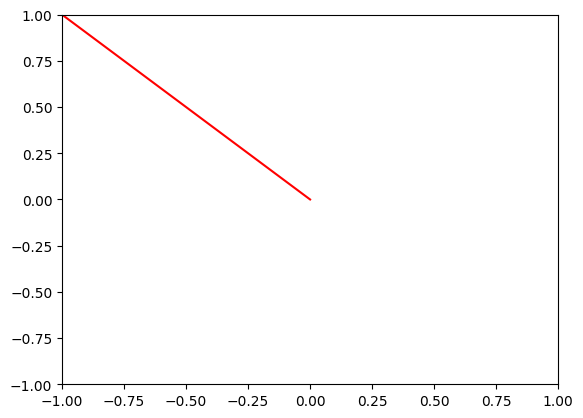

In [51]:
import matplotlib.pyplot as plt
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid()
# TODO


def plot_vector(vector, color="red"):
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.grid()
    plt.plot([0, vector[0]], [0, vector[1]], color=color)
    plt.show()

# Test
plot_vector(np.array([-1, 1]))

e, 7 pts) We want to visualize the rotation of our initial vector. To do this write a helper function called `extract_coordinates(vectors)` which takes as input a list of 2D vectors. This function should return 2 numpy arrays that contain the x-coordinates and y-coordinates, respectively. Test this function using your vector of outputs from the previous cell. Print out the x-coordinates and the y-coordinates.

In [52]:
# TODO
def extract_coordinates(vectors):
    xs = np.array([v[0] for v in vectors])
    ys = np.array([v[1] for v in vectors])
    return xs, ys

# Test
vectors = rotate_vectors(np.array([1, 0]), [0, 30, 60, 90])
x_coords, y_coords = extract_coordinates(vectors)
print(x_coords)
print(y_coords)

[1.00000000e+00 8.66025404e-01 5.00000000e-01 6.12323400e-17]
[0.        0.5       0.8660254 1.       ]


f, 3 pts) Let's put everything together now to visualize our rotations. You are given a starting vector `[1, 0]` and the following list of angles `[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]`. Use your previous functions to get the x- and y-coordinates from `extract_coordinates`.  Then plot the rotated vectors in the different colors specified by the `colors` array.

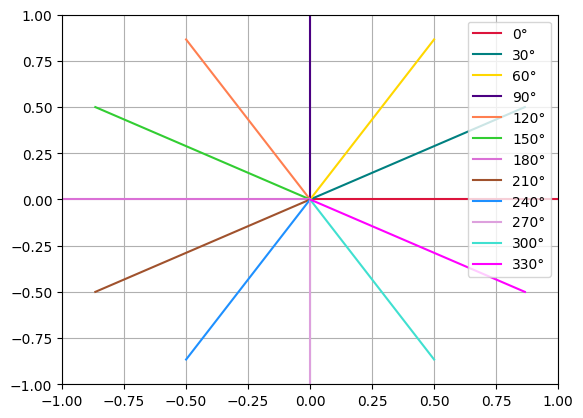

In [56]:
import matplotlib.pyplot as plt
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid()
colors = [
    "crimson", "teal", "gold", "indigo", "coral", 
    "limegreen", "orchid", "sienna", "dodgerblue", "plum",
    "turquoise", "magenta"
]

vector = np.array([1, 0])
angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

# TODO Use your previously created functions to get a list of x and y coordinates of the rotated vectors
x_coords, y_coords = extract_coordinates(rotated)

for i, xy in enumerate(zip(x_coords, y_coords)):
    x = x_coords[i].item()   # extract scalar from 0-dim/1-dim array
    y = y_coords[i].item()
    plt.plot([0, x], [0, y], color=colors[i], label=f"{angles[i]}°")


plt.legend()
plt.show()

# AI Statement (2 points)

Please put an X in the box that best matches your AI use for this homework ([X] in the markup will become a checked box).  There is no penalty for using AI, but we want to understand how you're using it.

- [ ] I did not use AI to complete this assignment.
- [X] I didn't use AI to debug or generate code, but I did use it as a Python reference.
- [ ] I didn't use AI to generate code, but I did use it to debug some code.
- [ ] I did use AI to generate some code, but not all the code for any problem.
- [ ] I used AI to solve at least one problem completely.

**When you are done, submit both your .ipynb (File->Download->Download .ipynb in Google Colab) and a PDF (File->Print->Save to PDF) to Blackboard where you found this assignment.**  (The backup PDF helps us give you points if there's a problem with your .ipynb.)